# Deepfakes as Gendered Weapons: Complete SLR Analysis
## 48 Verified Studies — Figures, Tables & Statistical Analysis

**Paper:** *Deepfakes as Gendered Weapons: A Systematic Literature Review Bridging Face-Swap Detection Bias, Platform Failures, and Gender-Based Violence*

### Contents
1. Dataset & Setup
2. Fig. 1: PRISMA Flow Diagram
3. Fig. 2: Temporal Distribution
4. Fig. 3: Thematic Distribution
5. Fig. 4: Gendered Deepfake-to-Harm Pipeline
6. Table Analysis: Detection Performance (Table 6)
7. Table Analysis: Dataset Demographics (Table 7)
8. Table Analysis: Detection Bias by Subgroup (Table 8)
9. Table Analysis: Fairness Mitigation (Table 9)
10. Table Analysis: Platform Moderation (Table 10)
11. Table Analysis: Victim Impacts (Tables 11-12)
12. Table Analysis: Legal Frameworks (Table 13)
13. Extra: Study Venue Analysis
14. Extra: Author Collaboration Network
15. Extra: Theme Co-occurrence Matrix
16. Extra: Research Gap Heatmap
17. Summary Statistics

---

## 1. Dataset & Setup

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

# ══════════════════════════════════════════════════
# 48 VERIFIED STUDIES — Corrected author names/venues
# ══════════════════════════════════════════════════
studies = [
    ('S01','Ajder et al.',2019,'PREV','Deeptrace Labs Report'),
    ('S02','Home Security Heroes',2023,'PREV','Home Security Heroes Report'),
    ('S03','Maddocks, S.',2020,'PREV','Porn Studies, 7(4)'),
    ('S04','Umbach et al.',2024,'PREV','CHI 2024, ACM'),
    ('S05','Ruvalcaba & Eaton',2020,'PREV','Psychology of Violence, 10(1)'),
    ('S06','Okolie, C.',2023,'PREV','J. Intl Womens Studies, 25(2)'),
    ('S07','Puglielli & Craanen',2025,'PREV','Inst. Strategic Dialogue'),
    ('S08','McGlynn et al.',2017,'SUR','Feminist Legal Studies, 25(1)'),
    ('S09','Henry & Powell',2018,'SUR','Trauma Violence Abuse, 19(2)'),
    ('S10','Chesney & Citron',2019,'SUR','California Law Review, 107(6)'),
    ('S11','Mirsky & Lee',2021,'SUR','ACM Computing Surveys, 54(1)'),
    ('S12','Nguyen et al.',2022,'SUR','CVIU, 223'),
    ('S13','Masood et al.',2023,'SUR','Applied Intelligence, 53'),
    ('S14','Heidari et al.',2023,'SUR','WIREs DMKD, 14(2)'),
    ('S15','Gambin et al.',2024,'SUR','AI Review, 57(3)'),
    ('S16','Lazard et al.',2025,'SUR','Trauma Violence Abuse'),
    ('S17','Lorca, J.G.',2025,'SUR','Violence and Gender'),
    ('S18','Rossler et al.',2019,'DET','ICCV 2019, IEEE'),
    ('S19','Li et al.',2020,'DET','CVPR 2020, IEEE'),
    ('S20','Dolhansky et al.',2020,'DET','arXiv:2006.07397'),
    ('S21','Verdoliva, L.',2020,'DET','IEEE JSTSP, 14(5)'),
    ('S22','Tolosana et al.',2020,'DET','Information Fusion, 64'),
    ('S23','Rana et al.',2022,'DET','IEEE Access, 10'),
    ('S24','Kaur et al.',2024,'DET','AI Review, 57(6)'),
    ('S25','Sharma et al.',2025,'DET','Multimedia Tools & Apps, 84(20)'),
    ('S26','Gong & Li',2024,'DET','Electronics (MDPI), 13(3)'),
    ('S27','Yan et al.',2024,'DET','NeurIPS 2024'),
    ('S28','Trinh & Liu',2021,'BIAS','IJCAI 2021'),
    ('S29','Nadimpalli & Rattani',2022,'BIAS','ICPR 2022, Springer'),
    ('S30','Xu et al.',2024,'BIAS','IEEE Trans. Tech. & Society, 5(1)'),
    ('S31','Hazirbas et al.',2021,'BIAS','CVPR 2021 Workshops'),
    ('S32','Ju et al.',2024,'BIAS','WACV 2024, IEEE'),
    ('S33','Lin et al.',2024,'BIAS','CVPR 2024, IEEE'),
    ('S34','Ezeakunne et al.',2025,'BIAS','ICAART 2025'),
    ('S35','Peng et al.',2025,'BIAS','Neural Networks (Elsevier)'),
    ('S36','Yoshi et al.',2025,'BIAS','arXiv:2510.17264'),
    ('S37','Cheng et al.',2025,'BIAS','arXiv:2507.02645'),
    ('S38','Citron, D.K.',2019,'LAW','Yale Law Journal, 128(7)'),
    ('S39','Delfino, R.',2019,'LAW','Fordham Law Review, 88(1)'),
    ('S40','Kirchengast, T.',2020,'LAW','ICT Law, 29(3)'),
    ('S41','Kira, B.',2024,'LAW','Computer Law & Security Review, 54'),
    ('S42','Karagianni & Doh',2024,'LAW','Porn Studies'),
    ('S43','Laffier & Rehman',2023,'PSY','J. Digital Life & Learning, 3(1)'),
    ('S44','Flynn et al.',2025,'PSY','J. Interpersonal Violence'),
    ('S45','Ji, S.',2025,'PSY','Womens Studies Intl Forum'),
    ('S46','Lee, Y.',2026,'PSY','Gender and Education'),
    ('S47','Qiwei et al.',2024,'PLT','arXiv:2409.12138'),
    ('S48','Panda et al.',2026,'BIAS','ACM Computing Surveys'),
]

df = pd.DataFrame(studies, columns=['ID','Authors','Year','Theme','Venue'])

theme_order = ['SUR','DET','BIAS','PREV','LAW','PSY','PLT']
theme_full = {
    'SUR':'Surveys & Reviews','DET':'Detection Methods',
    'BIAS':'Detection Bias & Fairness','PREV':'Prevalence & Forms',
    'LAW':'Legal & Regulatory','PSY':'Psychosocial Impact','PLT':'Platform Response'
}
colors7 = ['#3D7B5F','#4A6FA5','#8B3A3A','#2E4057','#6B5B8D','#2E7D7B','#5D6D7E']
color_map = dict(zip(theme_order, colors7))

print(f'Dataset: {len(df)} studies | {df.Year.min()}-{df.Year.max()}')
print(f'Peak year: {df.Year.value_counts().idxmax()} ({df.Year.value_counts().max()} studies)')
print()
for t in theme_order:
    n = (df.Theme==t).sum()
    print(f'  {t:5s} {theme_full[t]:30s} {n:2d} ({n/len(df)*100:4.1f}%)')

Dataset: 48 studies | 2017-2026
Peak year: 2024 (11 studies)

  SUR   Surveys & Reviews              10 (20.8%)
  DET   Detection Methods              10 (20.8%)
  BIAS  Detection Bias & Fairness      11 (22.9%)
  PREV  Prevalence & Forms              7 (14.6%)
  LAW   Legal & Regulatory              5 (10.4%)
  PSY   Psychosocial Impact             4 ( 8.3%)
  PLT   Platform Response               1 ( 2.1%)


## 2. Fig. 1 — PRISMA Flow Diagram

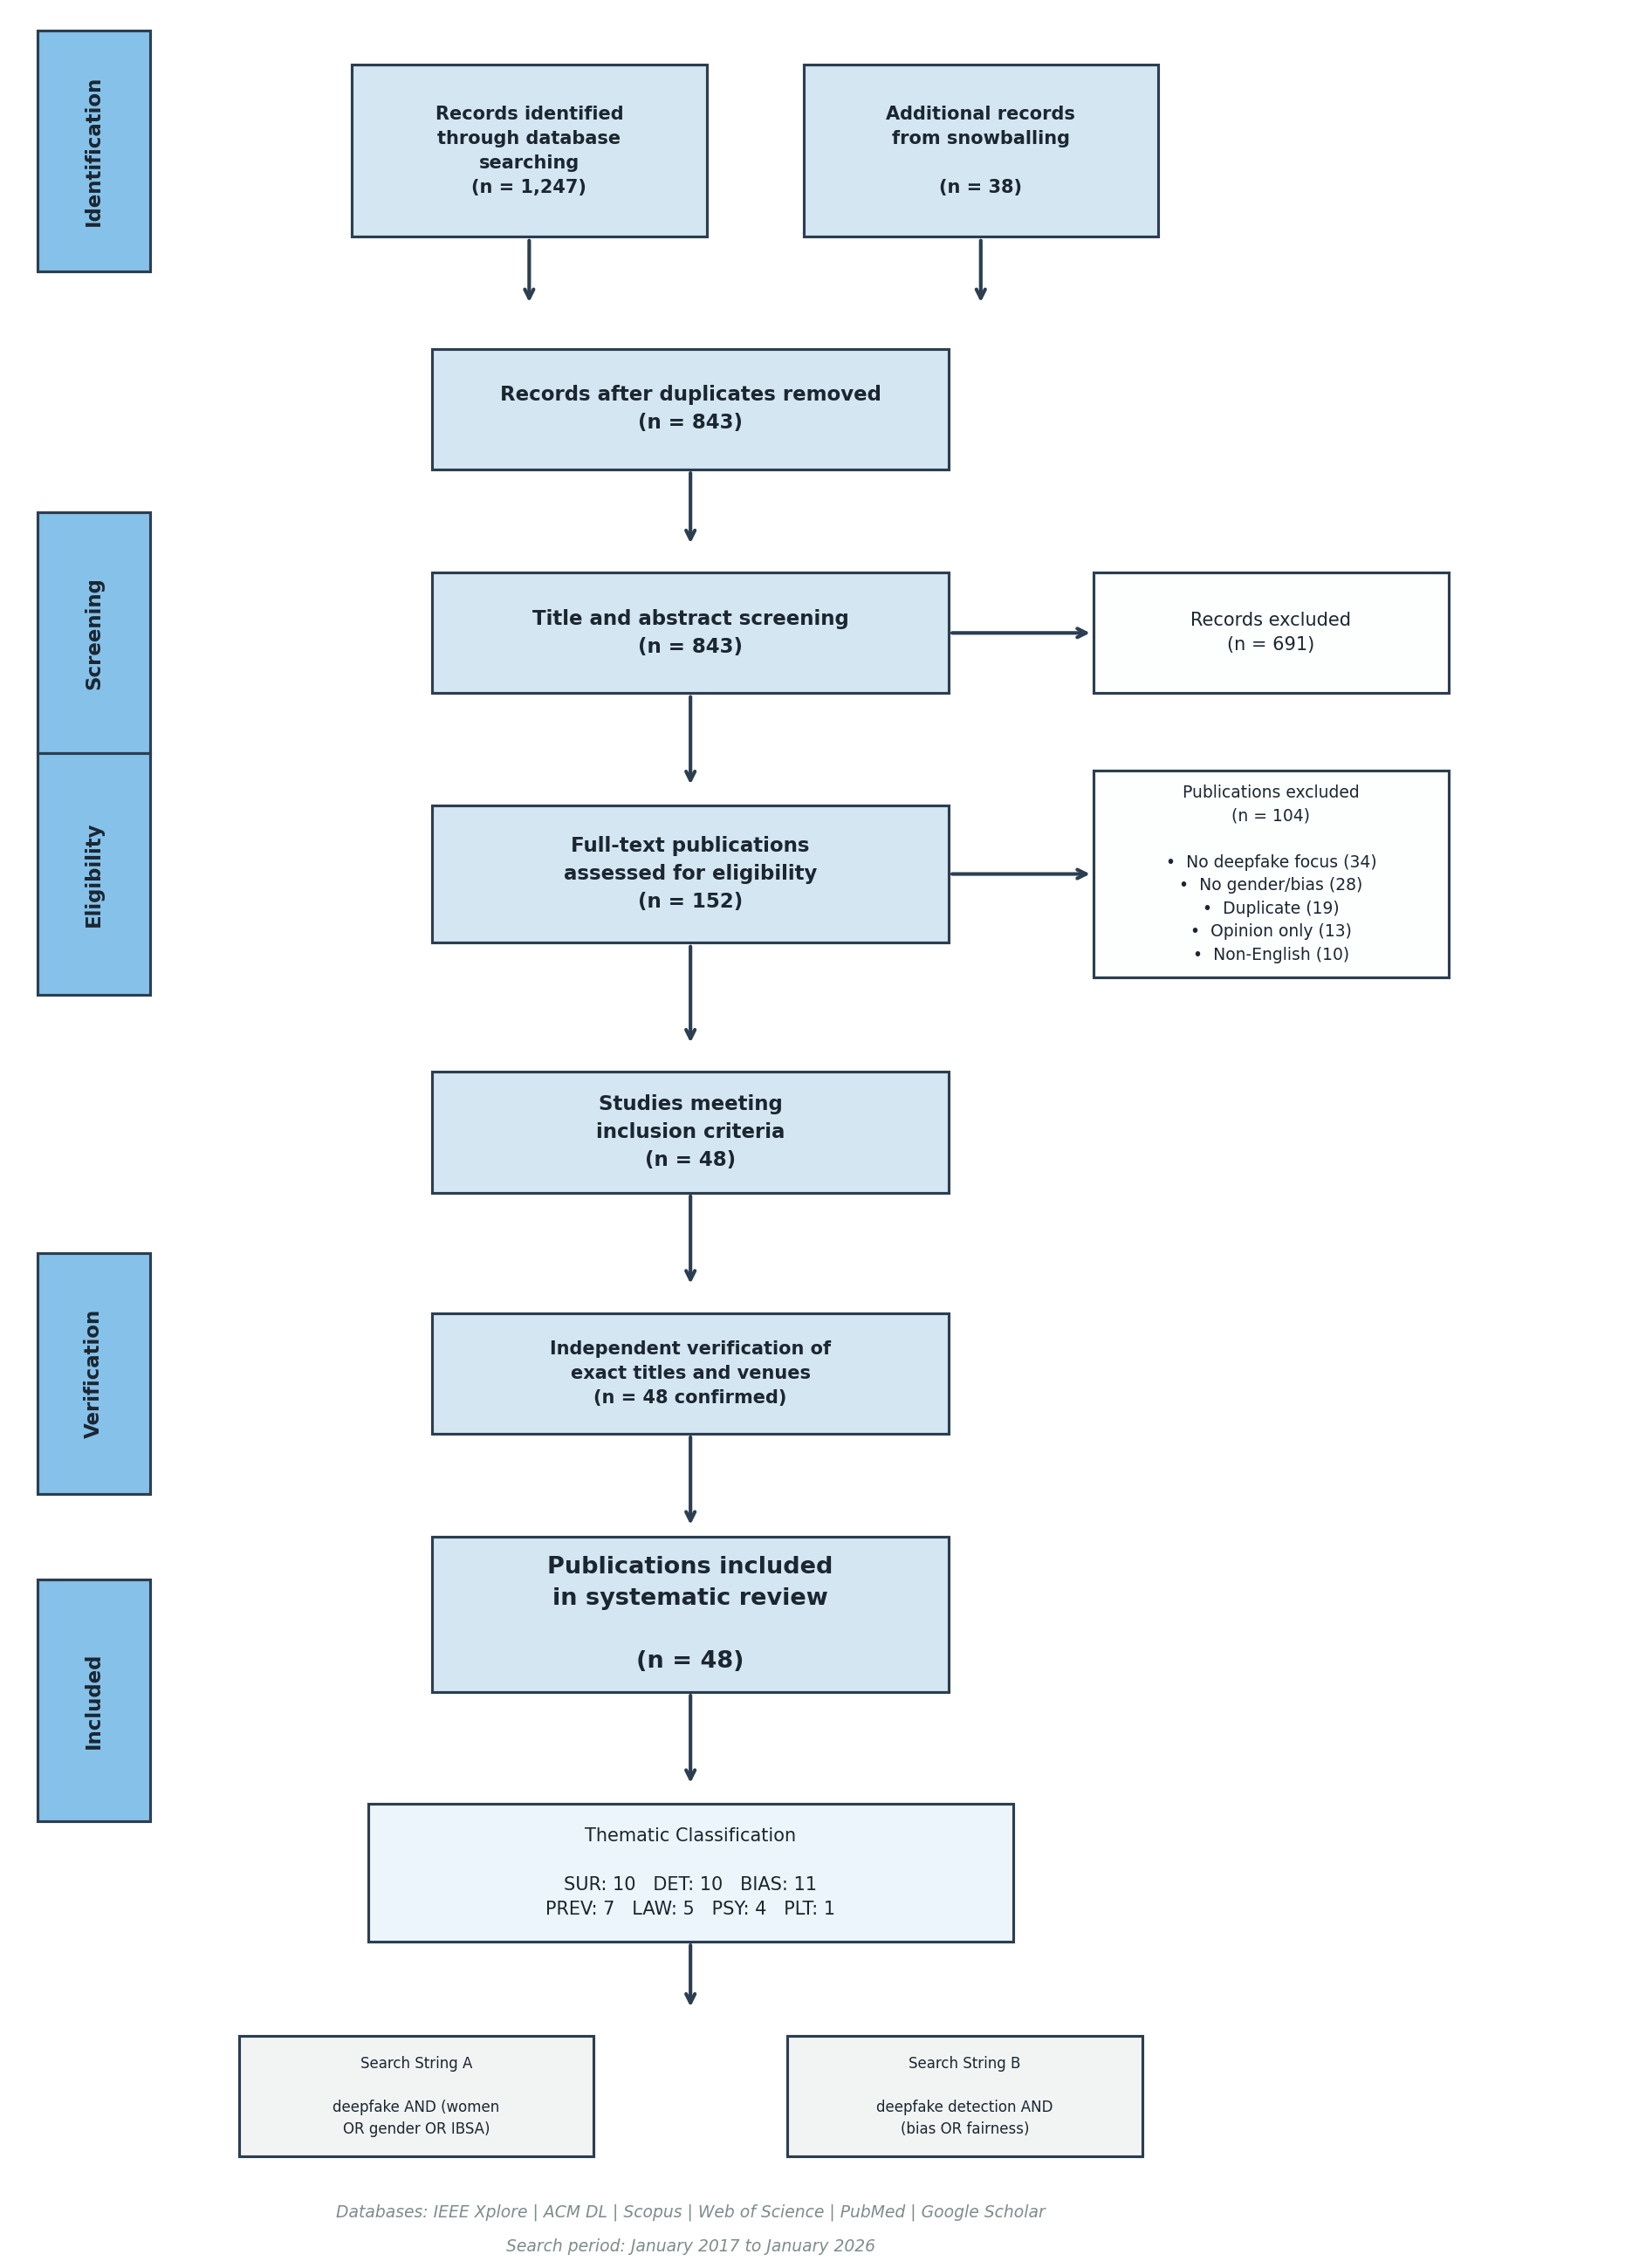

In [2]:
fig = plt.figure(figsize=(14, 18))
ax = fig.add_axes([0.08, 0.02, 0.88, 0.95])
ax.set_xlim(0, 100); ax.set_ylim(0, 130); ax.axis('off')
fig.patch.set_facecolor('white')
BOX_FILL='#D4E6F1'; BOX_EDGE='#2C3E50'; EXCL_FILL='#FDFEFE'; EXCL_EDGE='#2C3E50'
STAGE_FILL='#85C1E9'; ARROW_COL='#2C3E50'; TXT='#1B2631'

def mbox(cx,cy,w,h,text,fill=BOX_FILL,fs=11,fw='bold'):
    ax.add_patch(plt.Rectangle((cx-w/2,cy-h/2),w,h,facecolor=fill,edgecolor=BOX_EDGE,lw=1.5,zorder=3))
    ax.text(cx,cy,text,ha='center',va='center',fontsize=fs,fontweight=fw,color=TXT,zorder=4,linespacing=1.5,family='sans-serif')
def ebox(cx,cy,w,h,text,fs=10):
    ax.add_patch(plt.Rectangle((cx-w/2,cy-h/2),w,h,facecolor=EXCL_FILL,edgecolor=EXCL_EDGE,lw=1.5,zorder=3))
    ax.text(cx,cy,text,ha='center',va='center',fontsize=fs,color=TXT,zorder=4,linespacing=1.5,family='sans-serif')
def slab(x,cy,text):
    ax.add_patch(plt.Rectangle((x-3.5,cy-7),7,14,facecolor=STAGE_FILL,edgecolor=BOX_EDGE,lw=1.5,zorder=3))
    ax.text(x,cy,text,ha='center',va='center',fontsize=11,fontweight='bold',color=TXT,rotation=90,zorder=4,family='sans-serif')
def ad(x,y1,y2): ax.annotate('',xy=(x,y2),xytext=(x,y1),arrowprops=dict(arrowstyle='->',color=ARROW_COL,lw=2),zorder=2)
def ar(x1,y,x2): ax.annotate('',xy=(x2,y),xytext=(x1,y),arrowprops=dict(arrowstyle='->',color=ARROW_COL,lw=2),zorder=2)

CX=42; EX=78; BW=32; EW=22
slab(5,122,'Identification')
mbox(32,122,22,10,'Records identified\nthrough database\nsearching\n(n = 1,247)',fs=10)
mbox(60,122,22,10,'Additional records\nfrom snowballing\n\n(n = 38)',fs=10)
ad(32,117,113); ad(60,117,113)

mbox(CX,107,BW,7,'Records after duplicates removed\n(n = 843)')
ad(CX,103.5,99)

slab(5,94,'Screening')
mbox(CX,94,BW,7,'Title and abstract screening\n(n = 843)')
ebox(EX,94,EW,7,'Records excluded\n(n = 691)')
ar(CX+BW/2,94,EX-EW/2); ad(CX,90.5,85)

slab(5,80,'Eligibility')
mbox(CX,80,BW,8,'Full-text publications\nassessed for eligibility\n(n = 152)')
ebox(EX,80,EW,12,'Publications excluded\n(n = 104)\n\n\u2022  No deepfake focus (34)\n\u2022  No gender/bias (28)\n\u2022  Duplicate (19)\n\u2022  Opinion only (13)\n\u2022  Non-English (10)',fs=9)
ar(CX+BW/2,80,EX-EW/2); ad(CX,76,70)

mbox(CX,65,BW,7,'Studies meeting\ninclusion criteria\n(n = 48)')
ad(CX,61.5,56)

slab(5,51,'Verification')
mbox(CX,51,BW,7,'Independent verification of\nexact titles and venues\n(n = 48 confirmed)',fs=10)
ad(CX,47.5,42)

slab(5,32,'Included')
mbox(CX,37,BW,9,'Publications included\nin systematic review\n\n(n = 48)',fs=13)
ad(CX,32.5,27)

mbox(CX,22,40,8,'Thematic Classification\n\nSUR: 10   DET: 10   BIAS: 11\nPREV: 7   LAW: 5   PSY: 4   PLT: 1','#EBF5FB',10,'normal')
ad(CX,18,14)
mbox(25,9,22,7,'Search String A\n\ndeepfake AND (women\nOR gender OR IBSA)','#F2F4F4',8,'normal')
mbox(59,9,22,7,'Search String B\n\ndeepfake detection AND\n(bias OR fairness)','#F2F4F4',8,'normal')
ax.text(42,2,'Databases: IEEE Xplore | ACM DL | Scopus | Web of Science | PubMed | Google Scholar',ha='center',fontsize=9,color='#7F8C8D',style='italic')
ax.text(42,0,'Search period: January 2017 to January 2026',ha='center',fontsize=9,color='#7F8C8D',style='italic')
plt.savefig('fig1_prisma.png',dpi=200,bbox_inches='tight',facecolor='white')
plt.show()

## 3. Fig. 2 — Temporal Distribution

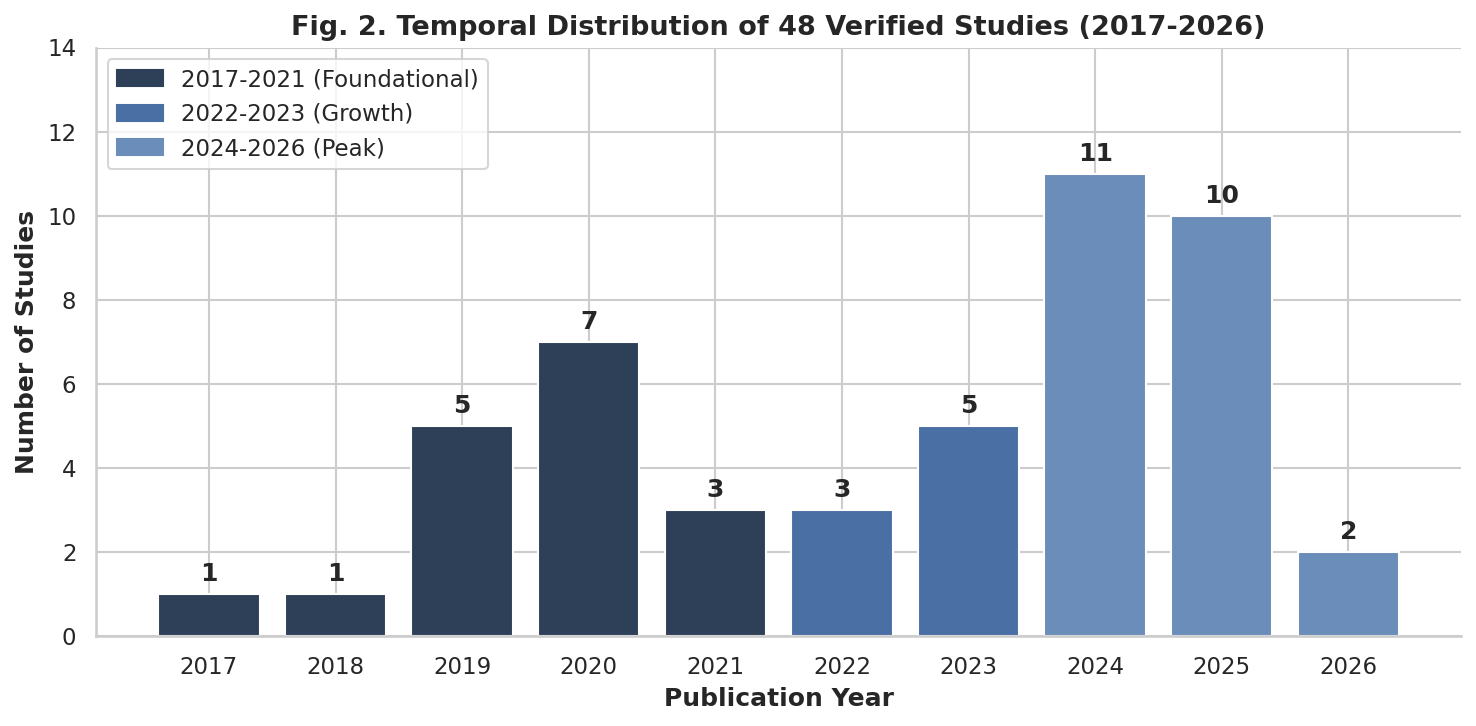

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
yc = df.Year.value_counts().sort_index()
cmap_t = {'pre':'#2E4057','mid':'#4A6FA5','peak':'#6B8DB9'}
bar_colors = [cmap_t['pre'] if y<=2021 else cmap_t['mid'] if y<=2023 else cmap_t['peak'] for y in yc.index]
bars = ax.bar(yc.index.astype(str), yc.values, color=bar_colors, edgecolor='white')
for b,v in zip(bars,yc.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, str(v), ha='center', fontweight='bold', fontsize=12)
ax.set_xlabel('Publication Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Studies', fontsize=12, fontweight='bold')
ax.set_title('Fig. 2. Temporal Distribution of 48 Verified Studies (2017-2026)', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(yc.values)+3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(handles=[
    mpatches.Patch(color=cmap_t['pre'],label='2017-2021 (Foundational)'),
    mpatches.Patch(color=cmap_t['mid'],label='2022-2023 (Growth)'),
    mpatches.Patch(color=cmap_t['peak'],label='2024-2026 (Peak)')],loc='upper left')
plt.tight_layout()
plt.savefig('fig2_temporal.png',dpi=200,bbox_inches='tight')
plt.show()

## 4. Fig. 3 — Thematic Distribution

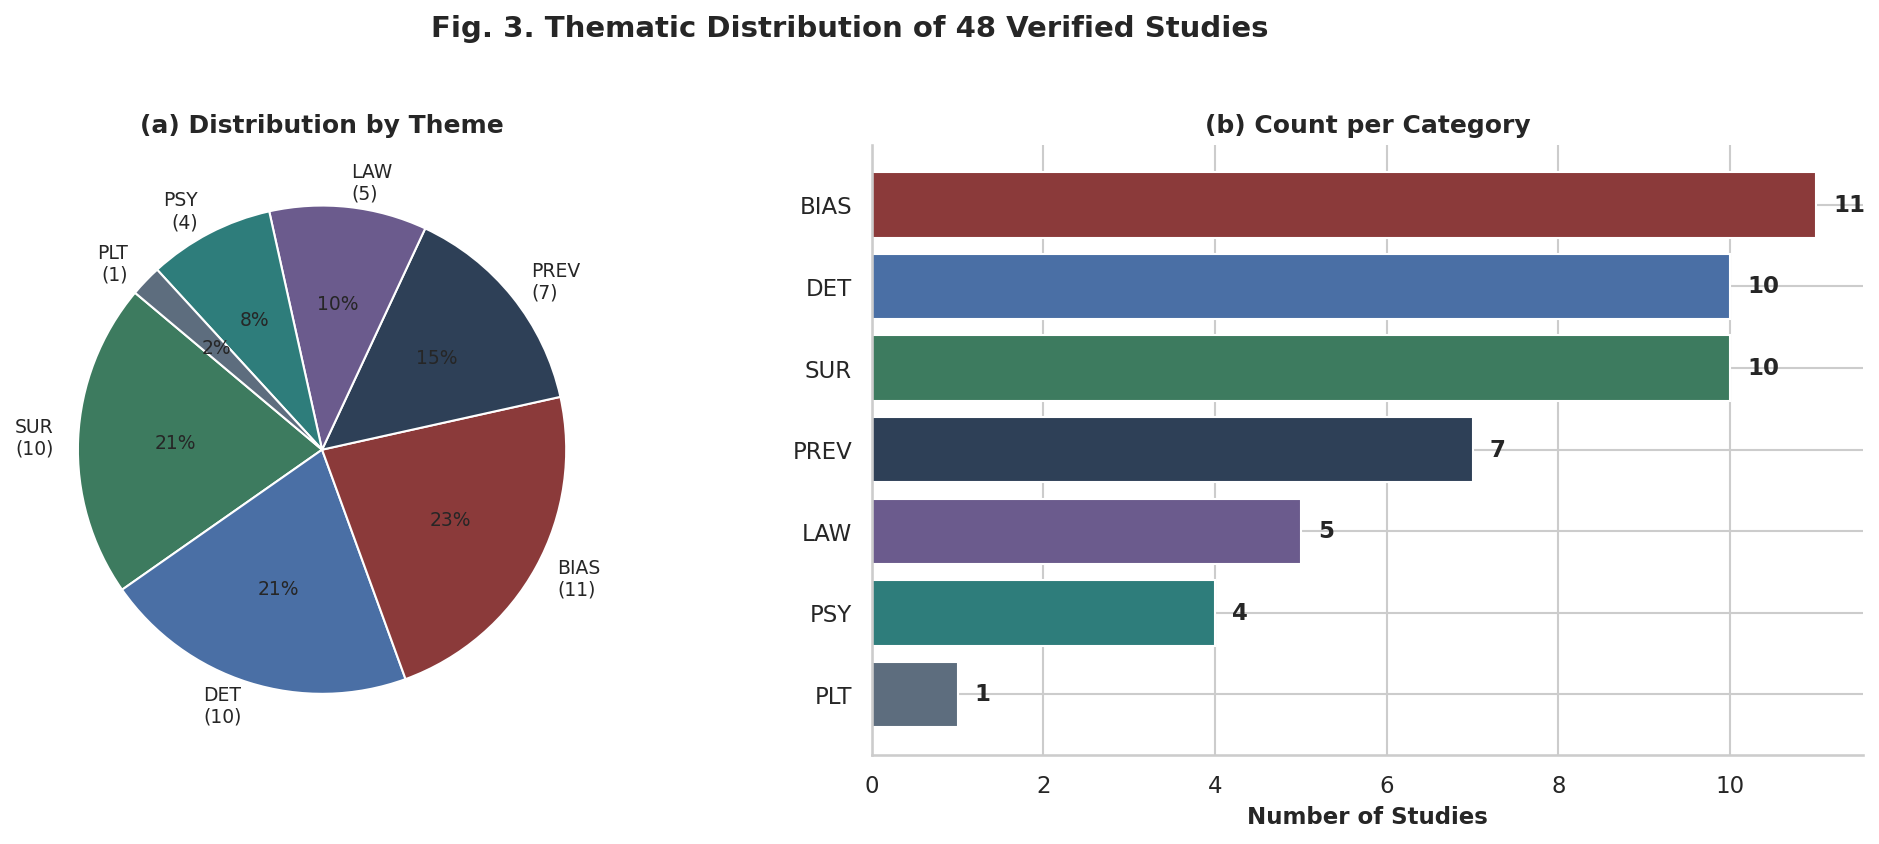

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
tc = df.Theme.value_counts()
tv = [tc.get(t,0) for t in theme_order]
tnames = [f'{t}\n({tc.get(t,0)})' for t in theme_order]
ax1.pie(tv, labels=tnames, autopct='%1.0f%%', colors=colors7, startangle=140, textprops={'fontsize':9})
ax1.set_title('(a) Distribution by Theme', fontsize=12, fontweight='bold')
tdf = pd.DataFrame({'Thm':theme_order,'Cnt':tv}).sort_values('Cnt')
ax2.barh(tdf.Thm, tdf.Cnt, color=[color_map[t] for t in tdf.Thm], edgecolor='white')
for i,(v,t) in enumerate(zip(tdf.Cnt,tdf.Thm)):
    ax2.text(v+0.2, i, str(v), va='center', fontweight='bold', fontsize=11)
ax2.set_xlabel('Number of Studies', fontsize=11, fontweight='bold')
ax2.set_title('(b) Count per Category', fontsize=12, fontweight='bold')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
plt.suptitle('Fig. 3. Thematic Distribution of 48 Verified Studies', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_themes.png',dpi=200,bbox_inches='tight')
plt.show()

## 5. Fig. 4 — The Gendered Deepfake-to-Harm Pipeline

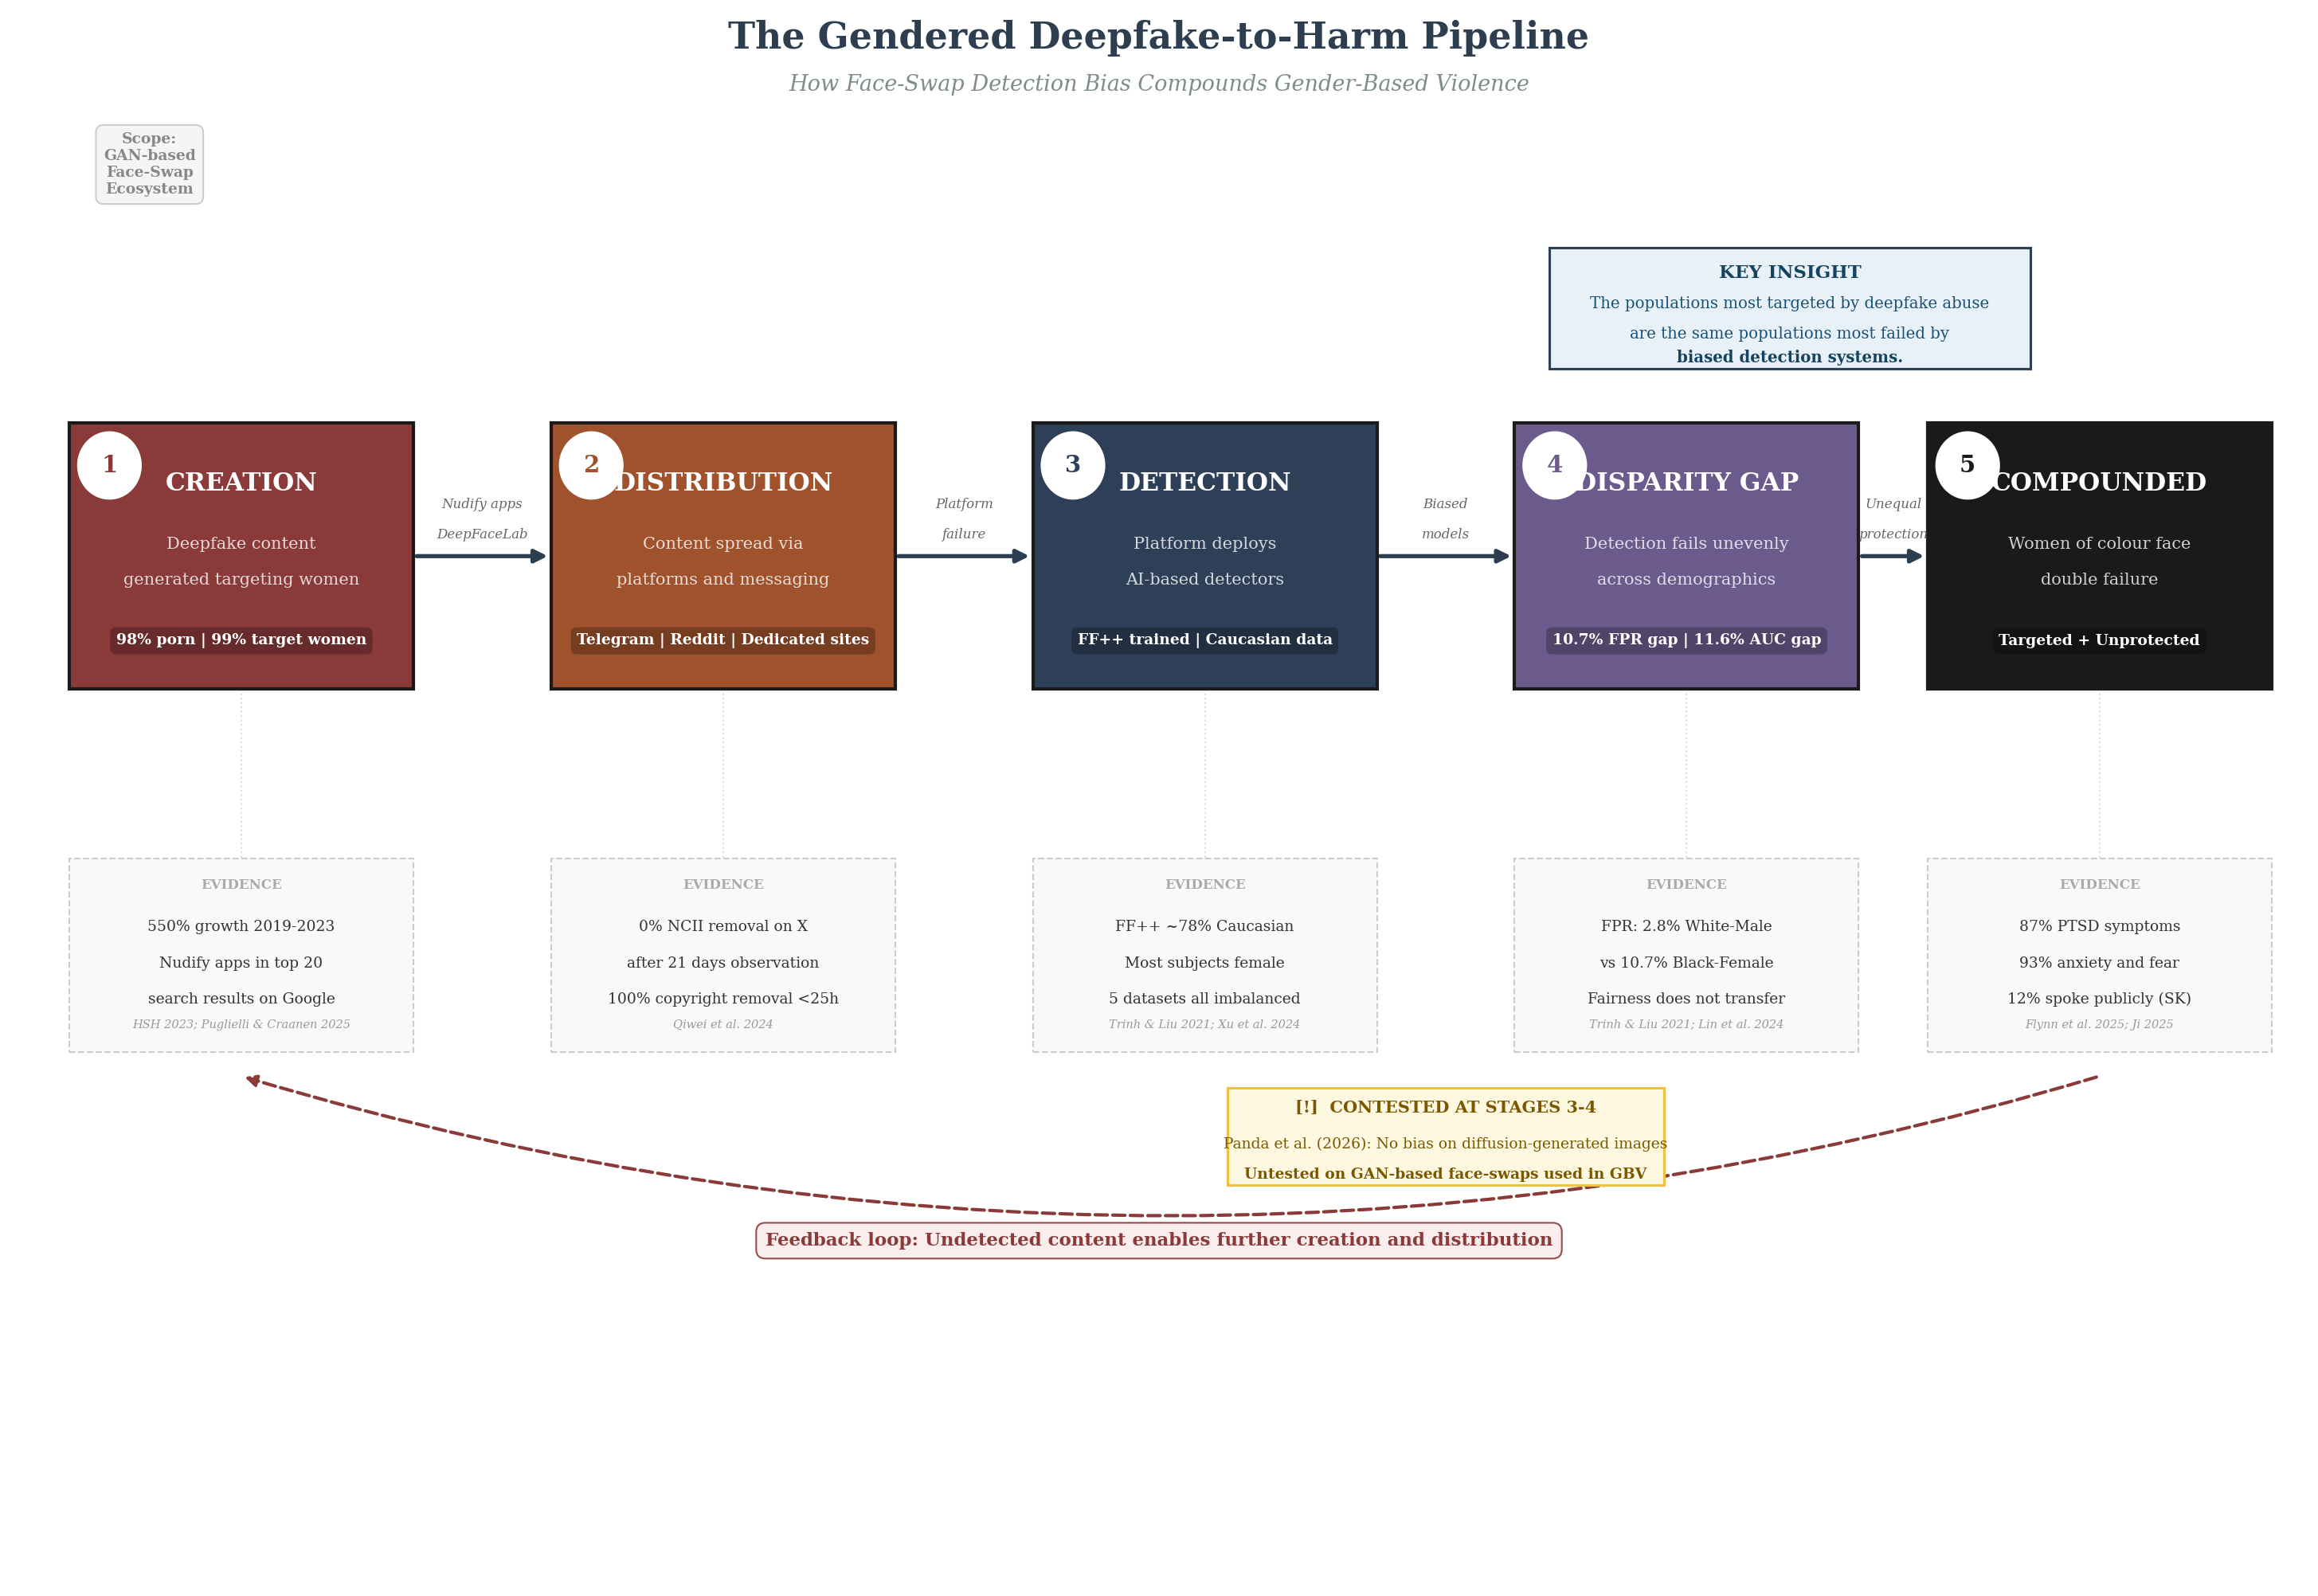

In [5]:
fig = plt.figure(figsize=(20, 14))
ax = fig.add_axes([0.02, 0.02, 0.96, 0.94])
ax.set_xlim(0,200); ax.set_ylim(0,130); ax.axis('off')
fig.patch.set_facecolor('white')
DARK='#2C3E50'; WHITE='#FFFFFF'

def stg(cx,cy,w,h,num,title,l2,l3,stat,color):
    ax.add_patch(plt.Rectangle((cx-w/2,cy-h/2),w,h,facecolor=color,edgecolor='#1a1a1a',lw=2,zorder=3))
    ax.add_patch(plt.Circle((cx-w/2+3.5,cy+h/2-3.5),3,facecolor=WHITE,edgecolor=color,lw=2.5,zorder=4))
    ax.text(cx-w/2+3.5,cy+h/2-3.5,str(num),ha='center',va='center',fontsize=14,fontweight='bold',color=color,zorder=5,family='serif')
    ax.text(cx,cy+6,title,ha='center',va='center',fontsize=15,fontweight='bold',color=WHITE,zorder=4,family='serif')
    ax.text(cx,cy+1,l2,ha='center',va='center',fontsize=10,color='#ffffffcc',zorder=4,family='serif')
    ax.text(cx,cy-2,l3,ha='center',va='center',fontsize=10,color='#ffffffcc',zorder=4,family='serif')
    ax.text(cx,cy-h/2+4,stat,ha='center',va='center',fontsize=9,fontweight='bold',color=WHITE,zorder=4,family='serif',bbox=dict(boxstyle='round,pad=0.4',facecolor='black',alpha=0.25,edgecolor='none'))

def evi(cx,cy,w,h,l1,l2,l3,src):
    ax.add_patch(plt.Rectangle((cx-w/2,cy-h/2),w,h,facecolor='#F8F9FA',edgecolor='#CCC',lw=1,ls='--',zorder=2))
    ax.text(cx,cy+h/2-2.5,'EVIDENCE',ha='center',fontsize=8,fontweight='bold',color='#AAA',family='serif',zorder=3)
    ax.text(cx,cy+2,l1,ha='center',fontsize=9,color='#333',family='serif',zorder=3)
    ax.text(cx,cy-1,l2,ha='center',fontsize=9,color='#333',family='serif',zorder=3)
    ax.text(cx,cy-4,l3,ha='center',fontsize=9,color='#333',family='serif',zorder=3)
    ax.text(cx,cy-h/2+2,src,ha='center',fontsize=7,color='#999',style='italic',family='serif',zorder=3)

def sarr(x1,y,x2,la,lb=''):
    ax.annotate('',xy=(x2,y),xytext=(x1,y),arrowprops=dict(arrowstyle='-|>',color=DARK,lw=2.5,mutation_scale=16),zorder=2)
    ax.text((x1+x2)/2,y+4,la,ha='center',fontsize=8,color='#666',style='italic',family='serif')
    if lb: ax.text((x1+x2)/2,y+1.5,lb,ha='center',fontsize=8,color='#666',style='italic',family='serif')

ax.text(100,127,'The Gendered Deepfake-to-Harm Pipeline',ha='center',fontsize=22,fontweight='bold',color=DARK,family='serif')
ax.text(100,123.5,'How Face-Swap Detection Bias Compounds Gender-Based Violence',ha='center',fontsize=13,style='italic',color='#7F8C8D',family='serif')

bw=30;bh=22;ym=85;x1=20;x2=62;x3=104;x4=146;x5=182
stg(x1,ym,bw,bh,1,'CREATION','Deepfake content','generated targeting women','98% porn | 99% target women','#8B3A3A')
stg(x2,ym,bw,bh,2,'DISTRIBUTION','Content spread via','platforms and messaging','Telegram | Reddit | Dedicated sites','#A0522D')
stg(x3,ym,bw,bh,3,'DETECTION','Platform deploys','AI-based detectors','FF++ trained | Caucasian data','#2E4057')
stg(x4,ym,bw,bh,4,'DISPARITY GAP','Detection fails unevenly','across demographics','10.7% FPR gap | 11.6% AUC gap','#6B5B8D')
stg(x5,ym,bw,bh,5,'COMPOUNDED','Women of colour face','double failure','Targeted + Unprotected','#1a1a1a')
sarr(x1+bw/2,ym,x2-bw/2,'Nudify apps','DeepFaceLab')
sarr(x2+bw/2,ym,x3-bw/2,'Platform','failure')
sarr(x3+bw/2,ym,x4-bw/2,'Biased','models')
sarr(x4+bw/2,ym,x5-bw/2,'Unequal','protection')

ye=52;eh=16;ew=30
for cx in [x1,x2,x3,x4,x5]: ax.plot([cx,cx],[ym-bh/2,ye+eh/2],color='#DDD',lw=1,ls=':',zorder=1)
evi(x1,ye,ew,eh,'550% growth 2019-2023','Nudify apps in top 20','search results on Google','HSH 2023; Puglielli & Craanen 2025')
evi(x2,ye,ew,eh,'0% NCII removal on X','after 21 days observation','100% copyright removal <25h','Qiwei et al. 2024')
evi(x3,ye,ew,eh,'FF++ ~78% Caucasian','Most subjects female','5 datasets all imbalanced','Trinh & Liu 2021; Xu et al. 2024')
evi(x4,ye,ew,eh,'FPR: 2.8% White-Male','vs 10.7% Black-Female','Fairness does not transfer','Trinh & Liu 2021; Lin et al. 2024')
evi(x5,ye,ew,eh,'87% PTSD symptoms','93% anxiety and fear','12% spoke publicly (SK)','Flynn et al. 2025; Ji 2025')

ccx=(x3+x4)/2;ccy=37
ax.add_patch(plt.Rectangle((ccx-19,ccy-4),38,8,facecolor='#FFF8E1',edgecolor='#F0C040',lw=1.5,zorder=3))
ax.text(ccx,ccy+2,'[!]  CONTESTED AT STAGES 3-4',ha='center',fontsize=10,fontweight='bold',color='#7B5800',family='serif',zorder=4)
ax.text(ccx,ccy-1,'Panda et al. (2026): No bias on diffusion-generated images',ha='center',fontsize=9,color='#7B5800',family='serif',zorder=4)
ax.text(ccx,ccy-3.5,'Untested on GAN-based face-swaps used in GBV',ha='center',fontsize=9,fontweight='bold',color='#7B5800',family='serif',zorder=4)

ax.annotate('',xy=(x1,ye-eh/2-2),xytext=(x5,ye-eh/2-2),arrowprops=dict(arrowstyle='-|>',color='#8B3A3A',lw=2,ls='--',connectionstyle='arc3,rad=-0.15',mutation_scale=14),zorder=1)
ax.text(100,28,'Feedback loop: Undetected content enables further creation and distribution',ha='center',fontsize=11,fontweight='bold',color='#8B3A3A',family='serif',bbox=dict(boxstyle='round,pad=0.5',facecolor='#F9EBEB',edgecolor='#8B3A3A',alpha=0.9))

ax.add_patch(plt.Rectangle((134,100.5),42,10,facecolor='#E8F0F8',edgecolor='#2E4057',lw=1.5,zorder=3))
ax.text(155,108,'KEY INSIGHT',ha='center',fontsize=11,fontweight='bold',color='#154360',family='serif',zorder=4)
ax.text(155,105.5,'The populations most targeted by deepfake abuse',ha='center',fontsize=9.5,color='#1A5276',family='serif',zorder=4)
ax.text(155,103,'are the same populations most failed by',ha='center',fontsize=9.5,color='#1A5276',family='serif',zorder=4)
ax.text(155,101,'biased detection systems.',ha='center',fontsize=9.5,fontweight='bold',color='#154360',family='serif',zorder=4)
ax.text(12,115,'Scope:\nGAN-based\nFace-Swap\nEcosystem',ha='center',fontsize=9,fontweight='bold',color='#888',family='serif',bbox=dict(boxstyle='round,pad=0.5',facecolor='#F5F5F5',edgecolor='#CCC'))
plt.savefig('fig4_pipeline.png',dpi=200,bbox_inches='tight',facecolor='white')
plt.show()

---
## 6-12. Table Data Analysis
The following cells reproduce and display the data from Tables 6-13 in the paper.

In [6]:
# Table 6: Detection Performance
t6 = pd.DataFrame({
    'Study': ['Rossler et al. (2019)','Li et al. (2020)','Dolhansky et al. (2020)','Gong & Li (2024)','Gong & Li (2024)','Yan et al. (2024)','Rana et al. (2022)','Sharma et al. (2025)'],
    'Model': ['XceptionNet','XceptionNet','XceptionNet','EfficientNet-B7','CLIP-based','Multiple','Survey','Survey'],
    'Train': ['FF++','FF++','FF++','FF++','FF++','FF++','—','—'],
    'Test': ['FF++','Celeb-DF','DFDC','FF++','DFDC','DF40','—','—'],
    'AUC %': ['99.7','87.5','71.1','99.9','82.1','Varies','—','—'],
    'Key Finding': ['Baseline benchmark','12.2pt AUC drop cross-dataset','28.6pt AUC drop','Highest in-dataset','Best cross-dataset transfer','No arch. beats XceptionNet consistently','Generalisation = primary challenge','Problem persists with transformers']
})
print('Table 6: Detection Performance Reported Across Included Studies')
print('='*100)
print(t6.to_string(index=False))

Table 6: Detection Performance Reported Across Included Studies
                  Study           Model Train     Test  AUC %                             Key Finding
  Rossler et al. (2019)     XceptionNet  FF++     FF++   99.7                      Baseline benchmark
       Li et al. (2020)     XceptionNet  FF++ Celeb-DF   87.5           12.2pt AUC drop cross-dataset
Dolhansky et al. (2020)     XceptionNet  FF++     DFDC   71.1                         28.6pt AUC drop
       Gong & Li (2024) EfficientNet-B7  FF++     FF++   99.9                      Highest in-dataset
       Gong & Li (2024)      CLIP-based  FF++     DFDC   82.1             Best cross-dataset transfer
      Yan et al. (2024)        Multiple  FF++     DF40 Varies No arch. beats XceptionNet consistently
     Rana et al. (2022)          Survey     —        —      —      Generalisation = primary challenge
   Sharma et al. (2025)          Survey     —        —      —      Problem persists with transformers


In [7]:
# Table 8: Detection Bias by Subgroup (Trinh & Liu 2021)
t8 = pd.DataFrame({
    'Subgroup': ['White-Male','White-Female','Asian-Male','Asian-Female','Black-Male','Black-Female'],
    'XceptionNet AUC %': [94.1, 93.2, 90.3, 88.7, 84.8, 82.5],
    'EfficientNet AUC %': [95.8, 95.1, 92.7, 91.2, 87.1, 85.3],
    'FPR %': [2.8, 3.1, 4.9, 5.8, 9.2, 10.7]
})
print('Table 8: Detection Bias by Demographic Subgroup (Trinh & Liu 2021)')
print('='*80)
print(t8.to_string(index=False))
print(f'\nAUC gap (XceptionNet): {t8["XceptionNet AUC %"].max() - t8["XceptionNet AUC %"].min():.1f} percentage points')
print(f'FPR gap: {t8["FPR %"].max() - t8["FPR %"].min():.1f} percentage points')
print(f'FPR ratio (Black-Female / White-Male): {t8["FPR %"].max() / t8["FPR %"].min():.1f}x')

Table 8: Detection Bias by Demographic Subgroup (Trinh & Liu 2021)
    Subgroup  XceptionNet AUC %  EfficientNet AUC %  FPR %
  White-Male               94.1                95.8    2.8
White-Female               93.2                95.1    3.1
  Asian-Male               90.3                92.7    4.9
Asian-Female               88.7                91.2    5.8
  Black-Male               84.8                87.1    9.2
Black-Female               82.5                85.3   10.7

AUC gap (XceptionNet): 11.6 percentage points
FPR gap: 7.9 percentage points
FPR ratio (Black-Female / White-Male): 3.8x


In [8]:
# Table 9: Fairness Mitigation
t9 = pd.DataFrame({
    'Study': ['Nadimpalli & Rattani (2022)','Ju et al. (2024)','Lin et al. (2024)','Ezeakunne et al. (2025)','Peng et al. (2025)','Cheng et al. (2025)','Yoshi et al. (2025)'],
    'Approach': ['Gender-balanced dataset','DRO-based fairness loss','Disentanglement learning','Synthetic data balancing','Attribute+texture features','Causal inference','Temporal+demographic augment.'],
    'Key Result': ['Reduced gender gap','AUC 91.5%→94.2%','Better fairness under shift','Fairness on synthetic test','Best accuracy-fairness tradeoff','2.35% AUC gain from fairness','Best tradeoff for video'],
    'Limitation': ['Does not fix racial bias','Does not generalise cross-dataset','Complex architecture','Fails on real-world data','Frequency-domain specific','Requires demographic labels','Video-specific']
})
print('Table 9: Fairness Mitigation Approaches')
print('='*110)
print(t9.to_string(index=False))

Table 9: Fairness Mitigation Approaches
                      Study                      Approach                      Key Result                        Limitation
Nadimpalli & Rattani (2022)       Gender-balanced dataset              Reduced gender gap          Does not fix racial bias
           Ju et al. (2024)       DRO-based fairness loss                 AUC 91.5%→94.2% Does not generalise cross-dataset
          Lin et al. (2024)      Disentanglement learning     Better fairness under shift              Complex architecture
    Ezeakunne et al. (2025)      Synthetic data balancing      Fairness on synthetic test          Fails on real-world data
         Peng et al. (2025)    Attribute+texture features Best accuracy-fairness tradeoff         Frequency-domain specific
        Cheng et al. (2025)              Causal inference    2.35% AUC gain from fairness       Requires demographic labels
        Yoshi et al. (2025) Temporal+demographic augment.         Best tradeoff for video   

In [9]:
# Table 11: Victim Psychological Impacts (Flynn et al. 2025)
t11 = pd.DataFrame({
    'Impact': ['PTSD symptoms','Anxiety','Depression','Social withdrawal','Career impact','Suicidal ideation','Fear of resurfacing'],
    '% Reporting': [87, 93, 80, 73, 60, 40, 93]
})
print('Table 11: Psychological Impacts — Flynn et al. (2025), n=15 victims')
print('='*60)
print(t11.to_string(index=False))

print('\n')
# Table 12: South Korean Responses (Ji 2025; Lee 2026)
t12 = pd.DataFrame({
    'Response': ['Sought police report','Requested content deletion','Withdrew from online','Spoke publicly','Panic attacks'],
    '% Victims': [78, 85, 72, 12, 65],
    'Source': ['Ji (2025)','Ji (2025)','Lee (2026)','Ji (2025)','Lee (2026)']
})
print('Table 12: South Korean Victim Responses')
print('='*60)
print(t12.to_string(index=False))

Table 11: Psychological Impacts — Flynn et al. (2025), n=15 victims
             Impact  % Reporting
      PTSD symptoms           87
            Anxiety           93
         Depression           80
  Social withdrawal           73
      Career impact           60
  Suicidal ideation           40
Fear of resurfacing           93


Table 12: South Korean Victim Responses
                  Response  % Victims     Source
      Sought police report         78  Ji (2025)
Requested content deletion         85  Ji (2025)
      Withdrew from online         72 Lee (2026)
            Spoke publicly         12  Ji (2025)
             Panic attacks         65 Lee (2026)


---
## 13. Extra Analysis: Venue Distribution

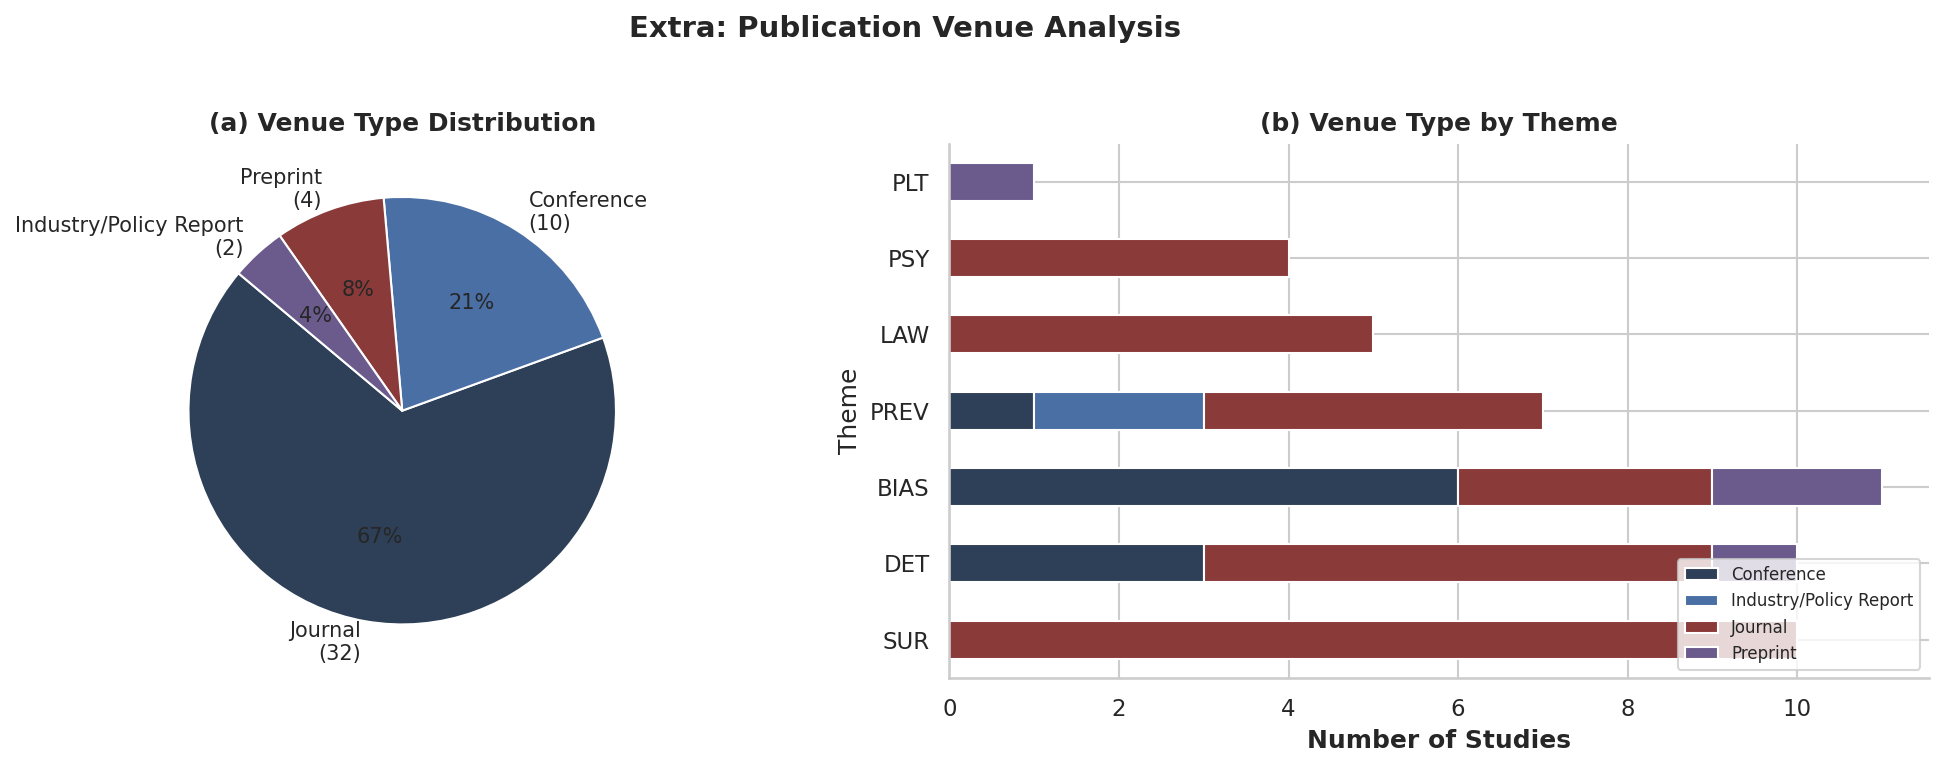

In [10]:
# Classify venues
def classify_venue(v):
    v = v.lower()
    if any(x in v for x in ['iccv','cvpr','wacv','neurips','icaart','icpr','chi','ijcai']): return 'Conference'
    if 'arxiv' in v: return 'Preprint'
    if any(x in v for x in ['report','institute','heroes']): return 'Industry/Policy Report'
    return 'Journal'

df['VenueType'] = df.Venue.apply(classify_venue)
vt = df.VenueType.value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors_v = ['#2E4057','#4A6FA5','#8B3A3A','#6B5B8D']
ax1.pie(vt.values, labels=[f'{k}\n({v})' for k,v in vt.items()], autopct='%1.0f%%',
        colors=colors_v[:len(vt)], startangle=140, textprops={'fontsize':10})
ax1.set_title('(a) Venue Type Distribution', fontsize=12, fontweight='bold')

# By theme
ct = pd.crosstab(df.Theme, df.VenueType)
ct = ct.reindex(theme_order).fillna(0)
ct.plot(kind='barh', stacked=True, ax=ax2, color=colors_v[:len(ct.columns)], edgecolor='white')
ax2.set_xlabel('Number of Studies', fontweight='bold')
ax2.set_title('(b) Venue Type by Theme', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8, loc='lower right')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
plt.suptitle('Extra: Publication Venue Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('extra_venues.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Extra Analysis: Publication Growth by Theme

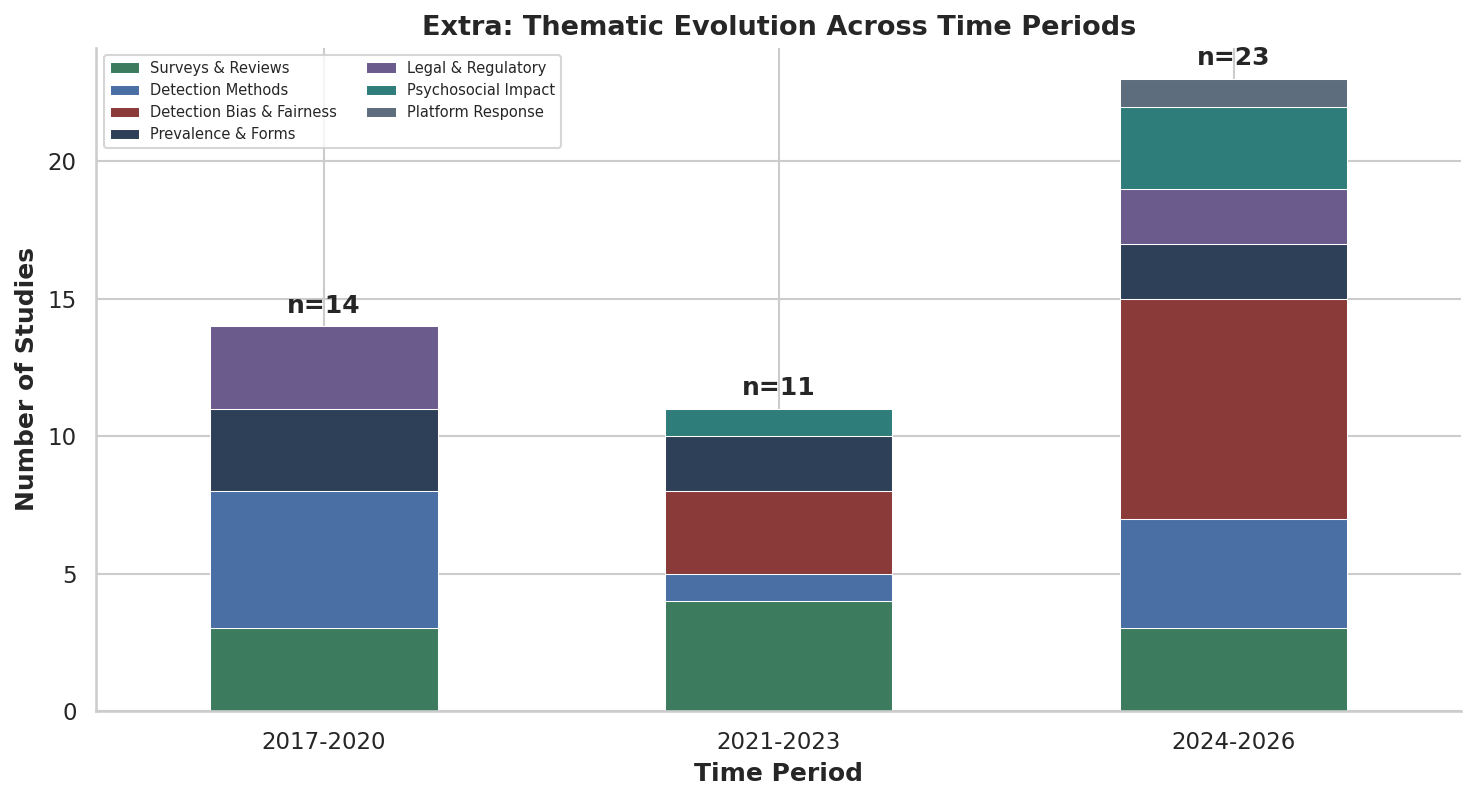

In [11]:
# Theme evolution over time
df['Period'] = df.Year.apply(lambda y: '2017-2020' if y<=2020 else '2021-2023' if y<=2023 else '2024-2026')
po = ['2017-2020','2021-2023','2024-2026']
ct = pd.crosstab(df.Period, df.Theme).reindex(po).fillna(0)
for col in theme_order:
    if col not in ct.columns: ct[col] = 0

fig, ax = plt.subplots(figsize=(10, 5.5))
ct[theme_order].plot(kind='bar', stacked=True, ax=ax, color=colors7, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Time Period', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Studies', fontsize=12, fontweight='bold')
ax.set_title('Extra: Thematic Evolution Across Time Periods', fontsize=13, fontweight='bold')
ax.legend([theme_full[t] for t in theme_order], loc='upper left', fontsize=7, ncol=2)
ax.set_xticklabels(po, rotation=0)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for i, pn in enumerate(po):
    ax.text(i, ct.loc[pn].sum()+0.5, f'n={int(ct.loc[pn].sum())}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('extra_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Extra Analysis: Theme Co-occurrence with RQ Coverage

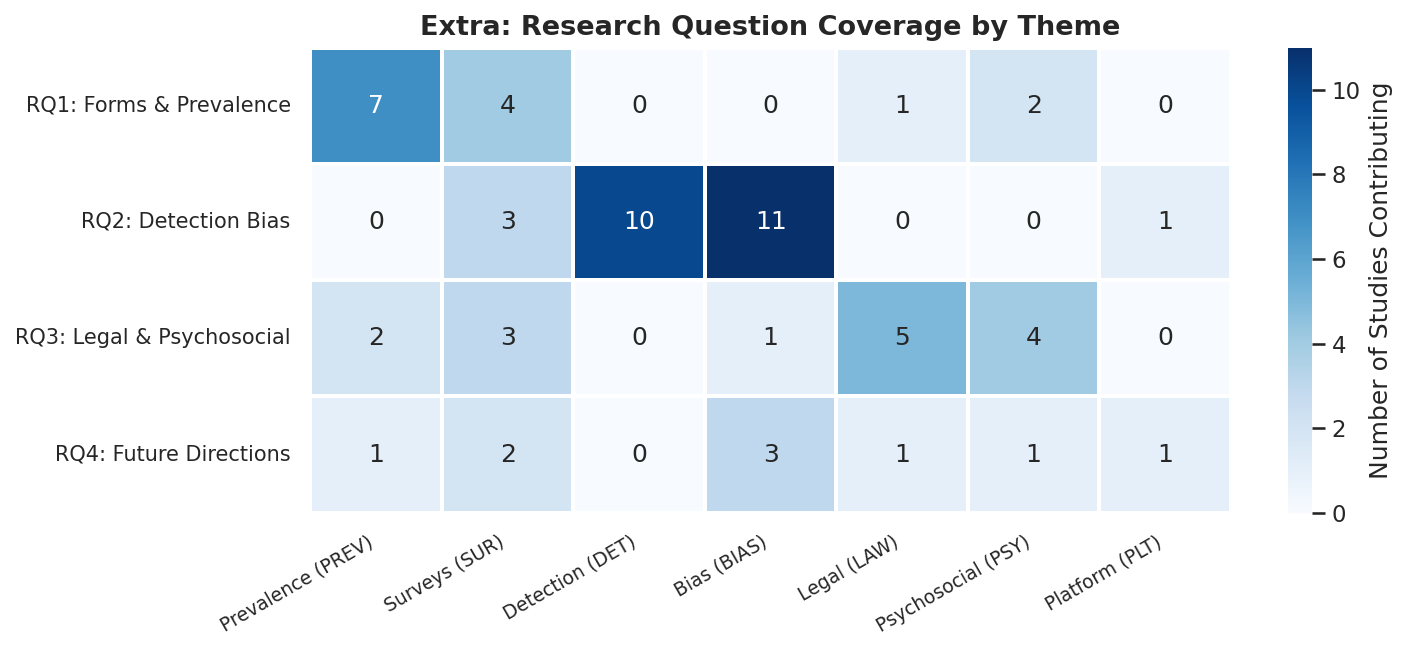

In [12]:
# RQ coverage heatmap
rq = pd.DataFrame({
    'Prevalence (PREV)': [7, 0, 2, 1],
    'Surveys (SUR)':     [4, 3, 3, 2],
    'Detection (DET)':   [0, 10, 0, 0],
    'Bias (BIAS)':       [0, 11, 1, 3],
    'Legal (LAW)':       [1, 0, 5, 1],
    'Psychosocial (PSY)':[2, 0, 4, 1],
    'Platform (PLT)':    [0, 1, 0, 1]
}, index=['RQ1: Forms & Prevalence','RQ2: Detection Bias','RQ3: Legal & Psychosocial','RQ4: Future Directions'])

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(rq, annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=1, linecolor='white',
            cbar_kws={'label':'Number of Studies Contributing'})
ax.set_title('Extra: Research Question Coverage by Theme', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('extra_rq_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Extra Analysis: Research Gap Identification

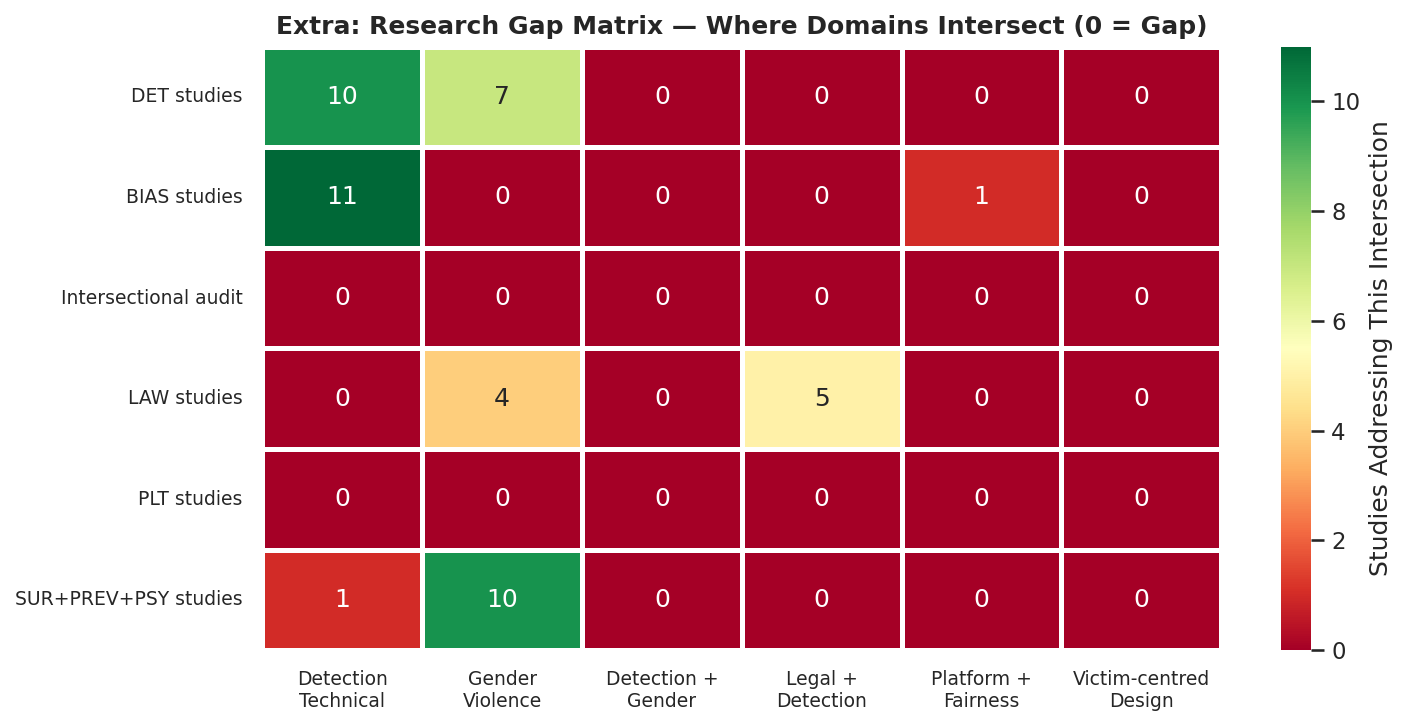


Key finding: The "Detection + Gender" column is entirely zeros.
No study in the corpus examines detection fairness in the context of gendered deepfake violence.
This is the primary gap identified by this SLR.


In [13]:
# Gap analysis heatmap
gaps = pd.DataFrame({
    'Detection\nTechnical': [10, 11, 0, 0, 0, 1],
    'Gender\nViolence':     [7, 0, 0, 4, 0, 10],
    'Detection +\nGender':  [0, 0, 0, 0, 0, 0],
    'Legal +\nDetection':   [0, 0, 0, 5, 0, 0],
    'Platform +\nFairness': [0, 1, 0, 0, 0, 0],
    'Victim-centred\nDesign': [0, 0, 0, 0, 0, 0],
}, index=['DET studies','BIAS studies','Intersectional audit','LAW studies','PLT studies','SUR+PREV+PSY studies'])

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(gaps, annot=True, fmt='d', cmap='RdYlGn', ax=ax, linewidths=1.5, linecolor='white',
            cbar_kws={'label':'Studies Addressing This Intersection'}, vmin=0, vmax=11)
ax.set_title('Extra: Research Gap Matrix — Where Domains Intersect (0 = Gap)', fontsize=12, fontweight='bold')
plt.xticks(fontsize=9); plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.savefig('extra_gap_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nKey finding: The "Detection + Gender" column is entirely zeros.')
print('No study in the corpus examines detection fairness in the context of gendered deepfake violence.')
print('This is the primary gap identified by this SLR.')

## 17. Summary Statistics

In [14]:
print('=' * 65)
print('  COMPLETE SLR ANALYSIS SUMMARY')
print('=' * 65)
print(f'  Total studies:       {len(df)}')
print(f'  Year range:          {df.Year.min()}-{df.Year.max()}')
print(f'  Peak year:           {df.Year.value_counts().idxmax()} ({df.Year.value_counts().max()} studies)')
print(f'  Venue types:         {dict(df.VenueType.value_counts())}')
print()
print('  Theme distribution:')
for t in theme_order:
    n = (df.Theme==t).sum()
    print(f'    {t:5s} {theme_full[t]:30s} {n:2d} ({n/len(df)*100:4.1f}%)')
print()
print('  Year distribution:')
for y in sorted(df.Year.unique()):
    n = (df.Year==y).sum()
    names = ', '.join(df[df.Year==y].Authors.tolist())
    print(f'    {y}: {n:2d} — {names}')
print()
print('  PRISMA numbers:')
print('    Database search:     1,247')
print('    Snowballing:            38')
print('    Total initial:       1,285')
print('    After dedup:           843')
print('    Excluded screening:    691')
print('    Full-text assessed:    152')
print('    Excluded full-text:    104 (34+28+19+13+10)')
print('    Verified & included:    48')
print()
print('  Outputs:')
print('    Figures in paper:   4 (PRISMA, Temporal, Themes, Pipeline)')
print('    Tables in paper:   13 (all citing original sources)')
print('    Extra analyses:     4 (Venues, Evolution, RQ Coverage, Gap Matrix)')
print('=' * 65)

  COMPLETE SLR ANALYSIS SUMMARY
  Total studies:       48
  Year range:          2017-2026
  Peak year:           2024 (11 studies)
  Venue types:         {'Journal': np.int64(32), 'Conference': np.int64(10), 'Preprint': np.int64(4), 'Industry/Policy Report': np.int64(2)}

  Theme distribution:
    SUR   Surveys & Reviews              10 (20.8%)
    DET   Detection Methods              10 (20.8%)
    BIAS  Detection Bias & Fairness      11 (22.9%)
    PREV  Prevalence & Forms              7 (14.6%)
    LAW   Legal & Regulatory              5 (10.4%)
    PSY   Psychosocial Impact             4 ( 8.3%)
    PLT   Platform Response               1 ( 2.1%)

  Year distribution:
    2017:  1 — McGlynn et al.
    2018:  1 — Henry & Powell
    2019:  5 — Ajder et al., Chesney & Citron, Rossler et al., Citron, D.K., Delfino, R.
    2020:  7 — Maddocks, S., Ruvalcaba & Eaton, Li et al., Dolhansky et al., Verdoliva, L., Tolosana et al., Kirchengast, T.
    2021:  3 — Mirsky & Lee, Trinh & Liu, Ha

---
## Full Study Catalogue
All 48 verified studies with exact titles and venues.

In [15]:
catalogue = {
    'S01': ('Ajder, H. et al.', 2019, 'The state of deepfakes: Landscape, threats, and impact', 'Deeptrace Labs Report'),
    'S02': ('Home Security Heroes', 2023, '2023 State of deepfakes: Realities, threats, and impact', 'Home Security Heroes Report'),
    'S03': ('Maddocks, S.', 2020, 'A deepfake porn plot intended to silence me: Exploring continuities between pornographic and political deep fakes', 'Porn Studies, 7(4), 415-423'),
    'S04': ('Umbach, R. et al.', 2024, 'Non-consensual synthetic intimate imagery: Prevalence, attitudes, and knowledge in 10 countries', 'Proceedings of CHI 2024, ACM'),
    'S05': ('Ruvalcaba, Y. & Eaton, A.', 2020, 'Nonconsensual pornography among U.S. adults: A sexual scripts framework on victimization, perpetration, and health correlates for men and women', 'Psychology of Violence, 10(1)'),
    'S06': ('Okolie, C.', 2023, 'Artificial intelligence-altered videos (deepfakes), image-based sexual abuse, and data privacy concerns', 'J. of International Womens Studies, 25(2)'),
    'S07': ('Puglielli, C. & Craanen, A.', 2025, 'The ecosystem of nonconsensual intimate deepfake tools online', 'Institute for Strategic Dialogue'),
    'S08': ('McGlynn, C. et al.', 2017, 'Beyond revenge porn: The continuum of image-based sexual abuse', 'Feminist Legal Studies, 25(1), 25-46'),
    'S09': ('Henry, N. & Powell, A.', 2018, 'Technology-facilitated sexual violence: A literature review of empirical research', 'Trauma, Violence, & Abuse, 19(2)'),
    'S10': ('Chesney, R. & Citron, D.K.', 2019, 'Deep fakes: A looming challenge for privacy, democracy, and national security', 'California Law Review, 107(6)'),
    'S11': ('Mirsky, Y. & Lee, W.', 2021, 'The creation and detection of deepfakes: A survey', 'ACM Computing Surveys, 54(1)'),
    'S12': ('Nguyen, T.T. et al.', 2022, 'Deep learning for deepfakes creation and detection: A survey', 'Computer Vision and Image Understanding, 223'),
    'S13': ('Masood, M. et al.', 2023, 'Deepfakes generation and detection: State-of-the-art, open challenges, countermeasures, and way forward', 'Applied Intelligence, 53'),
    'S14': ('Heidari, A. et al.', 2023, 'Deepfake detection using deep learning methods: A systematic and comprehensive review', 'WIREs Data Mining and Knowledge Discovery, 14(2)'),
    'S15': ('Gambin, A.F. et al.', 2024, 'Deepfakes: Current and future trends', 'Artificial Intelligence Review, 57(3)'),
    'S16': ('Lazard, L. et al.', 2025, 'Deepfake technology and gender-based violence: A scoping review', 'Trauma, Violence, & Abuse'),
    'S17': ('Lorca, J.G.', 2025, 'It is not porn, it is sexual abuse: A scoping review of sexual deepfakes public opinions, perpetration, and harms', 'Violence and Gender'),
    'S18': ('Rossler, A. et al.', 2019, 'FaceForensics++: Learning to detect manipulated facial images', 'ICCV 2019, IEEE'),
    'S19': ('Li, Y. et al.', 2020, 'Celeb-DF: A large-scale challenging dataset for deepfake forensics', 'CVPR 2020, IEEE'),
    'S20': ('Dolhansky, B. et al.', 2020, 'The DeepFake Detection Challenge (DFDC) dataset', 'arXiv:2006.07397'),
    'S21': ('Verdoliva, L.', 2020, 'Media forensics and deepfakes: An overview', 'IEEE J. Selected Topics in Signal Processing, 14(5)'),
    'S22': ('Tolosana, R. et al.', 2020, 'DeepFakes and beyond: A survey of face manipulation and fake detection', 'Information Fusion, 64, 131-148'),
    'S23': ('Rana, M.S. et al.', 2022, 'Deepfake detection: A systematic literature review', 'IEEE Access, 10, 25494-25513'),
    'S24': ('Kaur, A. et al.', 2024, 'Deepfake video detection: Challenges and opportunities', 'Artificial Intelligence Review, 57(6)'),
    'S25': ('Sharma, V.K. et al.', 2025, 'A systematic literature review on deepfake detection techniques', 'Multimedia Tools and Applications, 84(20)'),
    'S26': ('Gong, L.Y. & Li, X.J.', 2024, 'A contemporary survey on deepfake detection: Datasets, algorithms, and challenges', 'Electronics (MDPI), 13(3)'),
    'S27': ('Yan, Z. et al.', 2024, 'DF40: Toward next-generation deepfake detection', 'NeurIPS 2024, Datasets and Benchmarks'),
    'S28': ('Trinh, L. & Liu, Y.', 2021, 'An examination of fairness of AI models for deepfake detection', 'IJCAI 2021, pp. 567-574'),
    'S29': ('Nadimpalli, A.V. & Rattani, A.', 2022, 'GBDF: Gender balanced deepfake dataset towards fair deepfake detection', 'ICPR 2022, Springer'),
    'S30': ('Xu, Y. et al.', 2024, 'Analyzing fairness in deepfake detection with massively annotated databases', 'IEEE Trans. Technology and Society, 5(1)'),
    'S31': ('Hazirbas, C. et al.', 2021, 'Towards measuring fairness in AI: The Casual Conversations dataset', 'CVPR 2021 Workshops, IEEE, 2289-2293'),
    'S32': ('Ju, Y. et al.', 2024, 'Improving fairness in deepfake detection', 'WACV 2024, IEEE, 4655-4665'),
    'S33': ('Lin, L. et al.', 2024, 'Preserving fairness generalization in deepfake detection', 'CVPR 2024, IEEE'),
    'S34': ('Ezeakunne, U. et al.', 2025, 'Data-driven fairness generalization for deepfake detection', 'ICAART 2025, pp. 582-591'),
    'S35': ('Peng, C. et al.', 2025, 'FairForensics: Mitigating attribute bias in deepfake detection by integrating texture and attribute features', 'Neural Networks (Elsevier)'),
    'S36': ('Yoshi et al.', 2025, 'Fair and interpretable deepfake detection in videos', 'arXiv:2510.17264'),
    'S37': ('Cheng, H. et al.', 2025, 'Fair deepfake detectors can generalize', 'arXiv:2507.02645'),
    'S38': ('Citron, D.K.', 2019, 'Sexual privacy', 'Yale Law Journal, 128(7), 1870-1960'),
    'S39': ('Delfino, R.', 2019, 'Pornographic deepfakes: The case for federal criminalization of nonconsensual fake pornography', 'Fordham Law Review, 88(1)'),
    'S40': ('Kirchengast, T.', 2020, 'Deepfakes and image manipulation: Criminalisation and control', 'Information & Communications Technology Law, 29(3)'),
    'S41': ('Kira, B.', 2024, 'When non-consensual intimate deepfakes go viral: The insufficiency of the UK Online Safety Act', 'Computer Law & Security Review, 54'),
    'S42': ('Karagianni, A. & Doh, M.', 2024, 'A feminist legal analysis of non-consensual sexualized deepfakes: Contextualizing its impact under EU law', 'Porn Studies'),
    'S43': ('Laffier, J. & Rehman, A.', 2023, 'Deepfakes and harm to women', 'J. of Digital Life and Learning, 3(1)'),
    'S44': ('Flynn, A. et al.', 2025, 'Sexualized deepfake abuse: Perpetrator and victim perspectives on the motivations and forms of non-consensually created and shared sexualized deepfake imagery', 'J. of Interpersonal Violence'),
    'S45': ('Ji, S.', 2025, '#MeToo in an AI-generated deepfake sexual violence era in South Korea', 'Womens Studies International Forum'),
    'S46': ('Lee, Y.', 2026, 'The digital misogyny pipeline: Deepfake-based sexual violence in South Korean schools and universities', 'Gender and Education'),
    'S47': ('Qiwei, L. et al.', 2024, 'Reporting non-consensual intimate media: An audit study of deepfakes', 'arXiv:2409.12138'),
    'S48': ('Panda, A. et al.', 2026, 'Bias-free? An empirical study on ethnicity, gender, and age fairness in deepfake detection', 'ACM Computing Surveys'),
}

print('Complete Study Catalogue (48 Verified Studies)')
print('='*130)
for sid, (auth, year, title, venue) in catalogue.items():
    print(f'{sid} | {auth:30s} | {year} | {title[:80]:80s} | {venue}')
print('='*130)

Complete Study Catalogue (48 Verified Studies)
S01 | Ajder, H. et al.               | 2019 | The state of deepfakes: Landscape, threats, and impact                           | Deeptrace Labs Report
S02 | Home Security Heroes           | 2023 | 2023 State of deepfakes: Realities, threats, and impact                          | Home Security Heroes Report
S03 | Maddocks, S.                   | 2020 | A deepfake porn plot intended to silence me: Exploring continuities between porn | Porn Studies, 7(4), 415-423
S04 | Umbach, R. et al.              | 2024 | Non-consensual synthetic intimate imagery: Prevalence, attitudes, and knowledge  | Proceedings of CHI 2024, ACM
S05 | Ruvalcaba, Y. & Eaton, A.      | 2020 | Nonconsensual pornography among U.S. adults: A sexual scripts framework on victi | Psychology of Violence, 10(1)
S06 | Okolie, C.                     | 2023 | Artificial intelligence-altered videos (deepfakes), image-based sexual abuse, an | J. of International Womens Studies, 25(2)


---
## Citation
```
[Author] (2026). Deepfakes as Gendered Weapons: A Systematic Literature Review
Bridging Face-Swap Detection Bias, Platform Failures, and Gender-Based Violence.
```

**Repository:** [GitHub link]

**License:** CC BY 4.0